In [1]:
import os
import pandas as pd
import random
import shutil

data_path = r'C:\Users\chloe\OneDrive\Desktop\swallow EMG\data\participants\1\extracted signals'

In [2]:
os.chdir("..") 

from src import feature_extraction, models, utils, results

exclude = ['oral prep 0']
df, class_map = feature_extraction.make_df(data_path, exclude)

df

substance volume         1                                               \
                           min       max peak_to_peak        mav        rms   
0           0     10  -89.8215   73.5244     163.3459  10.123081  15.526914   
1           0     10 -113.9200   86.1073     200.0273   9.896790  16.791919   
2           0     10  -82.3953   84.7438     167.1391  10.532140  16.572327   
3           0     10 -194.0030  125.6940     319.6970  11.846242  20.842131   
4           0     10 -117.7260   84.5021     202.2281  11.854229  18.994828   
..        ...    ...       ...       ...          ...        ...        ...   
440        10     20  -69.3289   69.5755     138.9044  10.175371  15.426147   
441        10     20  -86.3076   74.0248     160.3324  11.288252  18.020237   
442        10     20  -93.5527   91.9620     185.5147  11.081596  17.163182   
443        10     20  -95.3684   61.4933     156.8617  11.031382  16.758005   
444        10     20  -95.7571   91.9919     187.7490  13.782139  20.737838   

                                    ...        22                         \
       variance  ssc     abs_diffs  ... abs_diffs   total_power     iemg   
0    241.085047  432   8511.370464  ...    426580  2.855146e+07  3322060   
1    281.968302  440   8262.519721  ...    449540  2.839299e+07  4038860   
2    274.641479  427   8938.223938  ...    391580  2.837819e+07  4577860   
3    434.394440  432   9634.231501  ...    458780  2.361374e+07  5437880   
4    360.801618  394   9543.440074  ...    353780  3.530921e+07  5531540   
..          ...  ...           ...  ...       ...           ...      ...   
440  237.965865  396   8874.451929  ...    329560  2.012949e+07  3136980   
441  324.728936  421   9792.563997  ...    396620  3.994745e+07  3865400   
442  294.572930  417   8838.968969  ...    390740  3.174081e+07  4293940   
443  280.830702  390   9634.328738  ...    390040  3.482336e+07  3813460   
444  430.057924  403  11234.928474  ...    462560  2.527296e+07  3783080   

                                                                \
    shannon_entropy mean_freq median_freq peak_freq  bandwidth   
0          4.040291  7.067688         4.0       2.0  11.468772   
1          4.537548  5.096151         2.0       1.0  10.656156   
2          4.487950  4.361224         2.0       1.0   9.277570   
3          4.410476  8.145964         6.0      13.0   8.524833   
4          4.641191  3.729602         1.0       1.0   7.157294   
..              ...       ...         ...       ...        ...   
440        3.997013  5.815702         3.0       3.0   6.709104   
441        4.062512  5.177273         3.0       2.0   7.256091   
442        4.641988  4.827547         3.0       3.0   7.216130   
443        4.344892  5.345078         4.0       2.0   6.659081   
444        4.518855  5.978335         4.0       3.0   9.129009   

                                     
    spectral_edge_freq crest_factor  
0                 17.0     3.383382  
1                 16.0     2.549675  
2                 15.0     2.601074  
3                 16.0     3.326772  
4                 14.0     2.306773  
..                 ...          ...  
440               15.0     4.349148  
441               13.0     4.329699  
442               14.0     2.561073  
443               14.0     3.117836  
444               15.0     2.974145  

[445 rows x 376 columns]

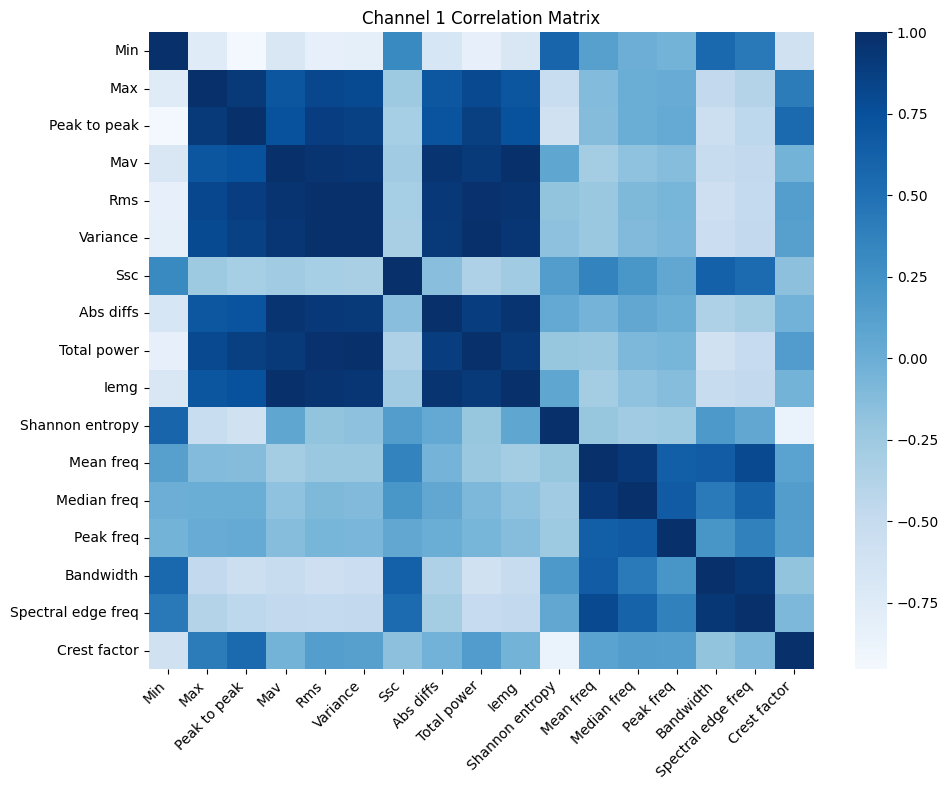

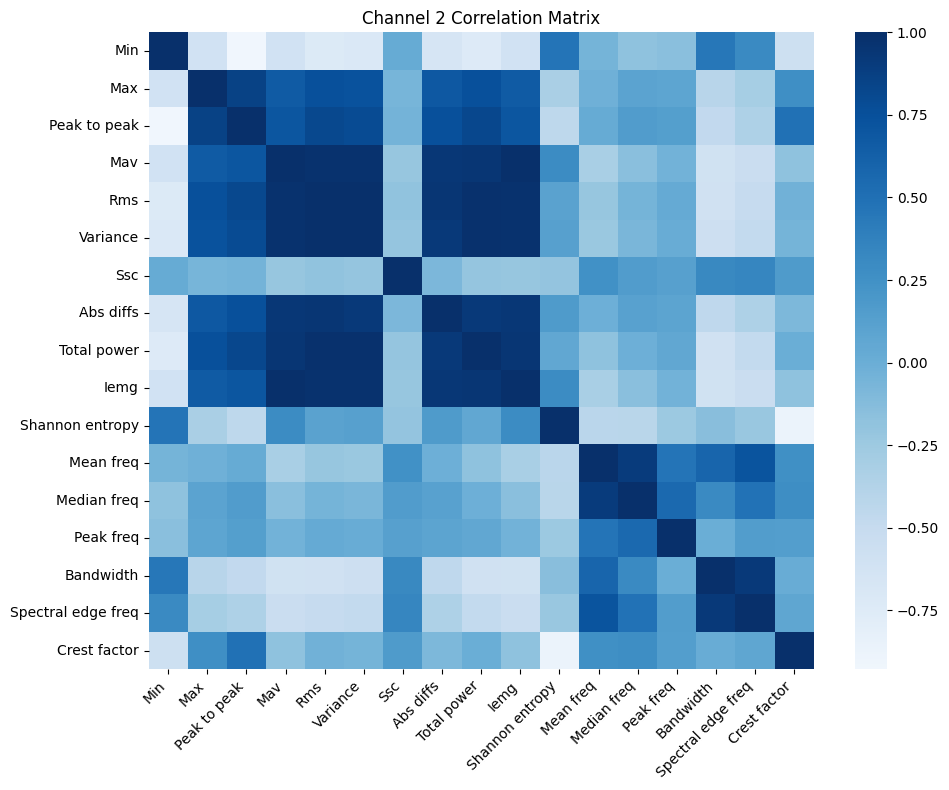

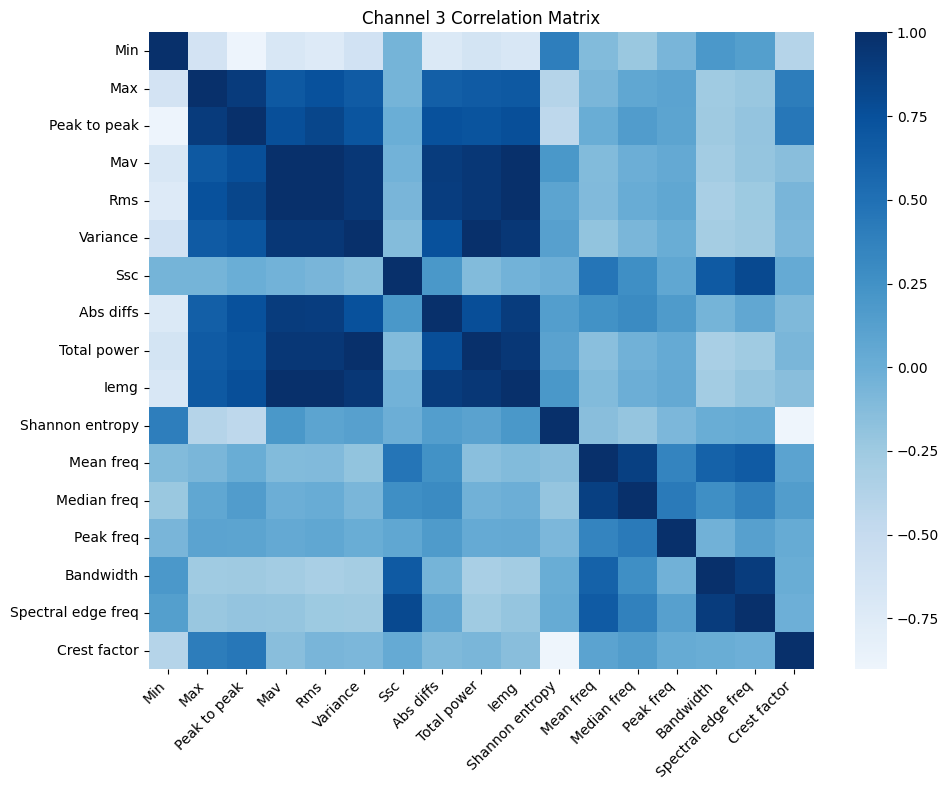

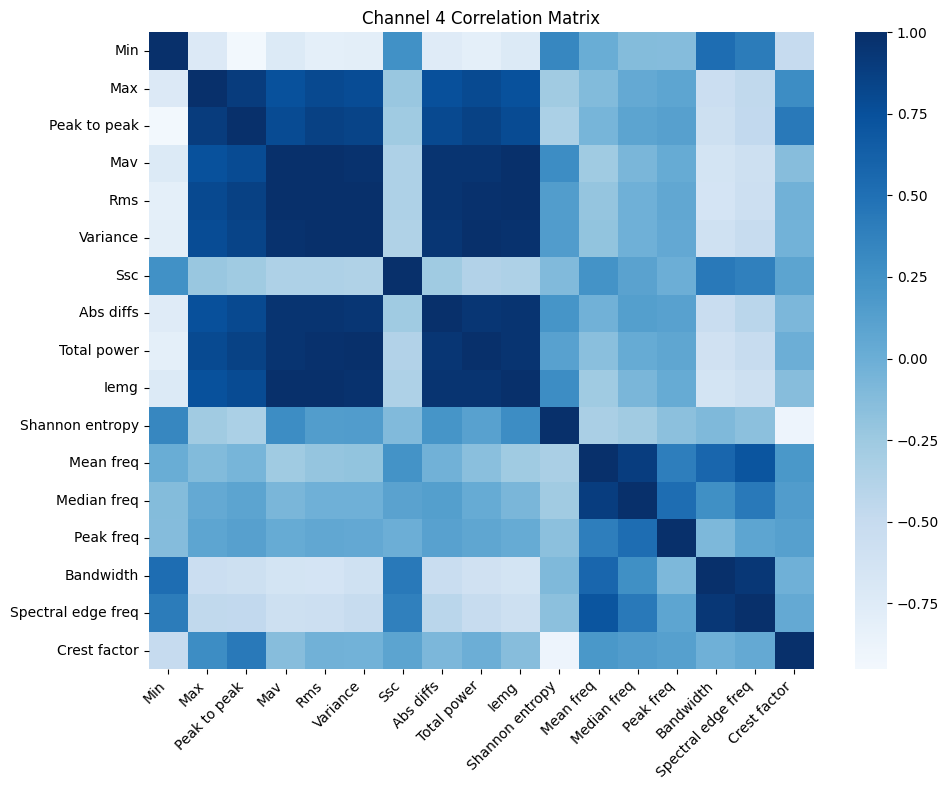

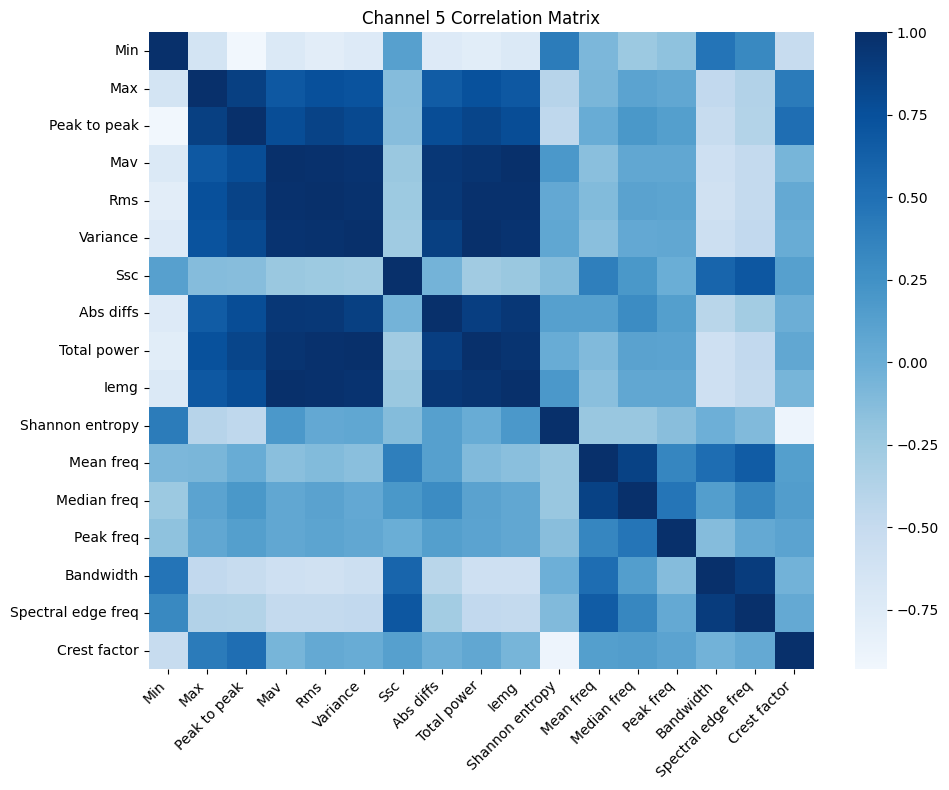

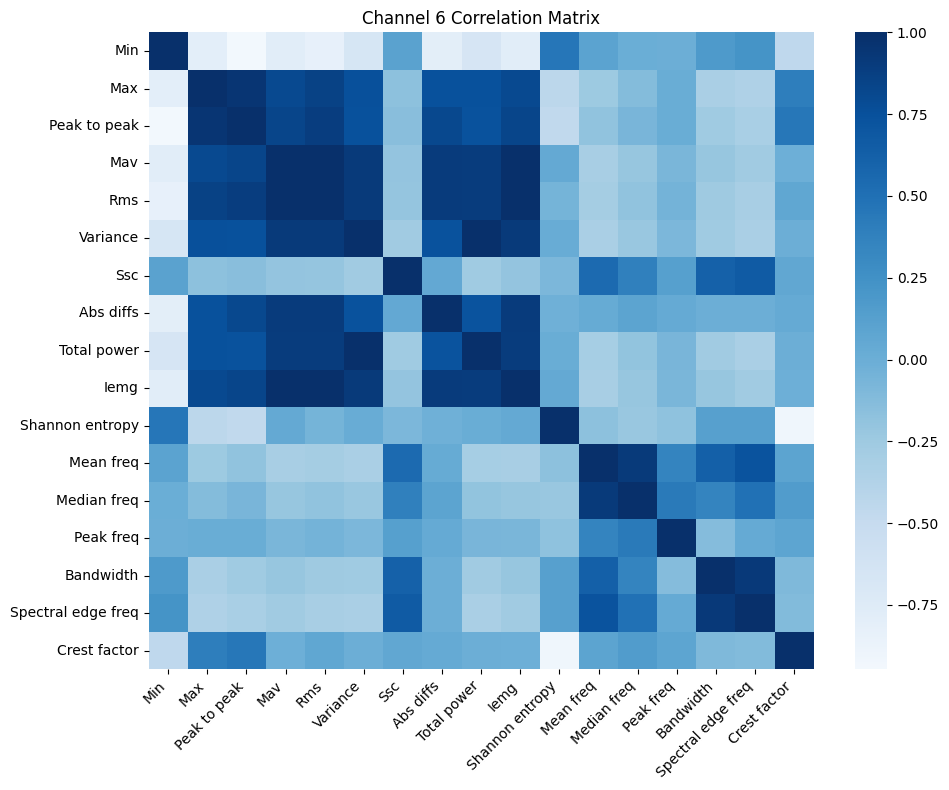

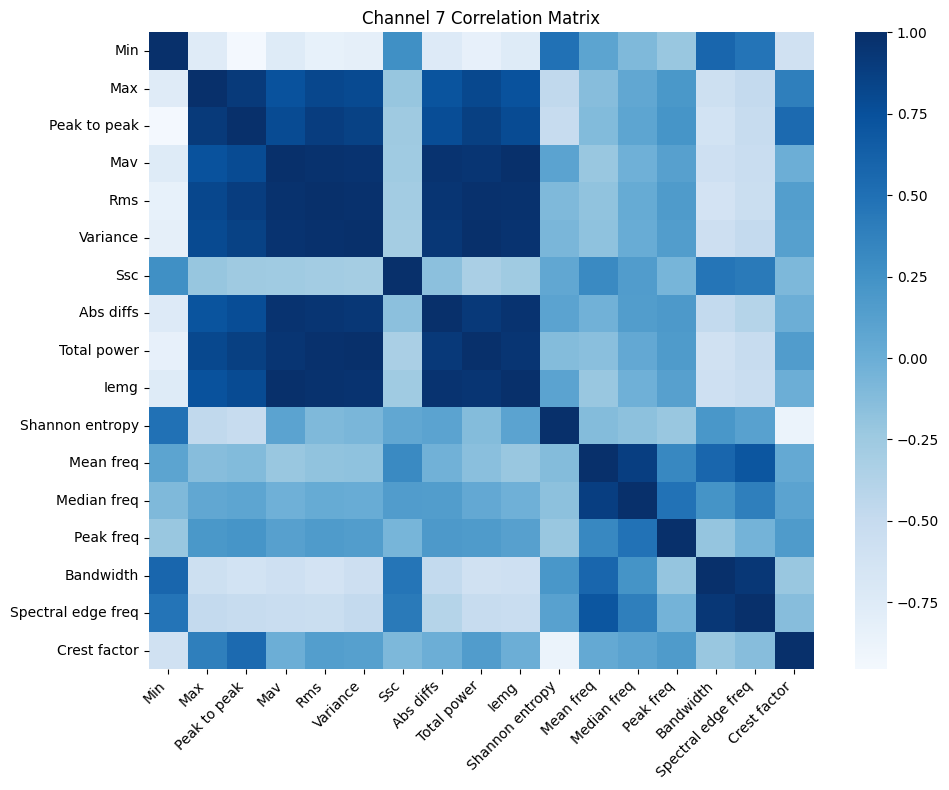

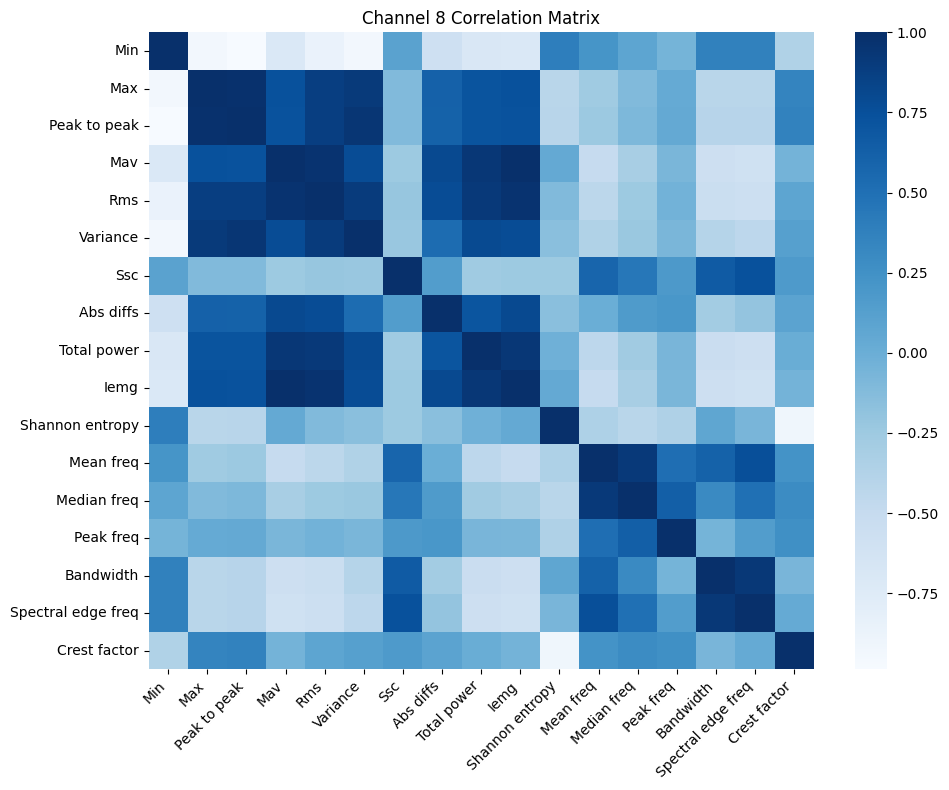

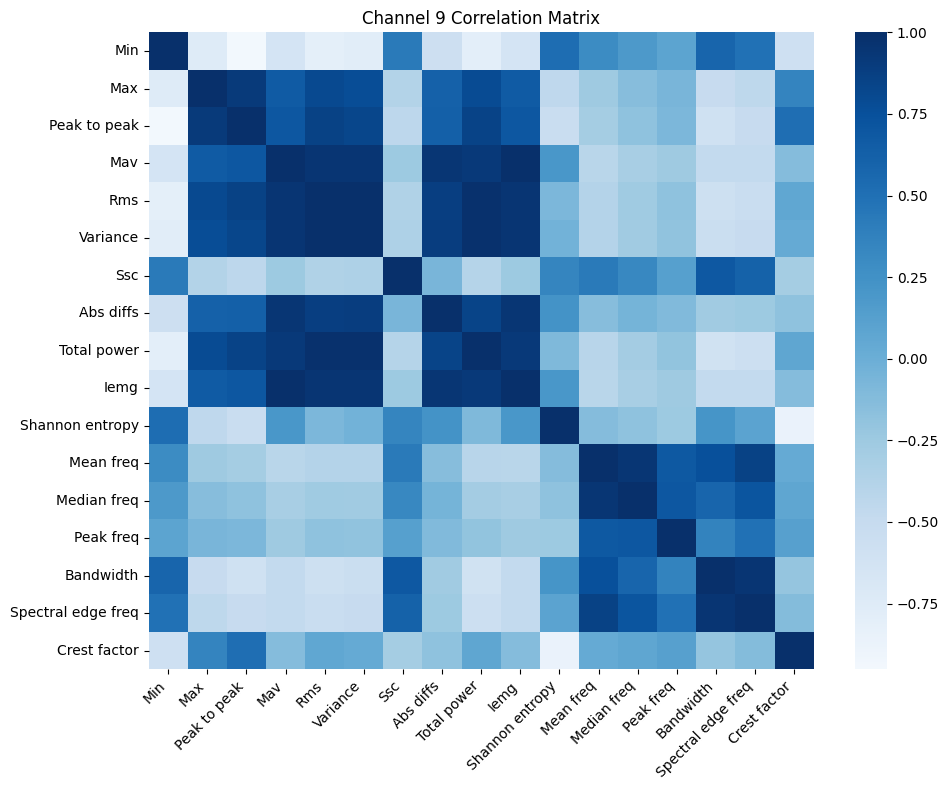

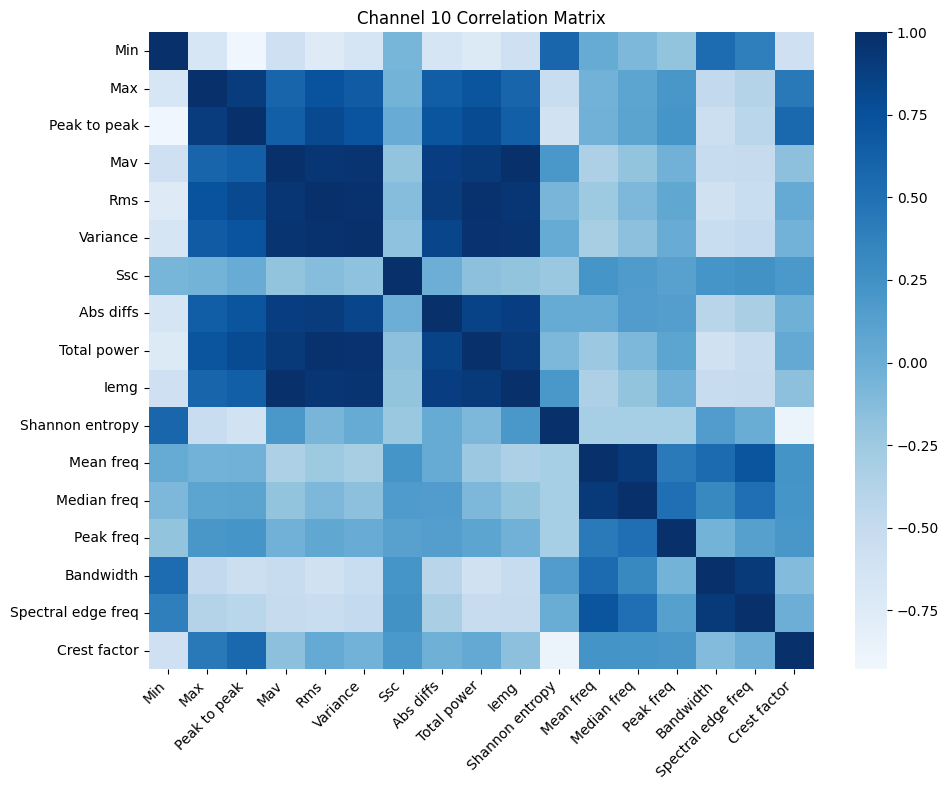

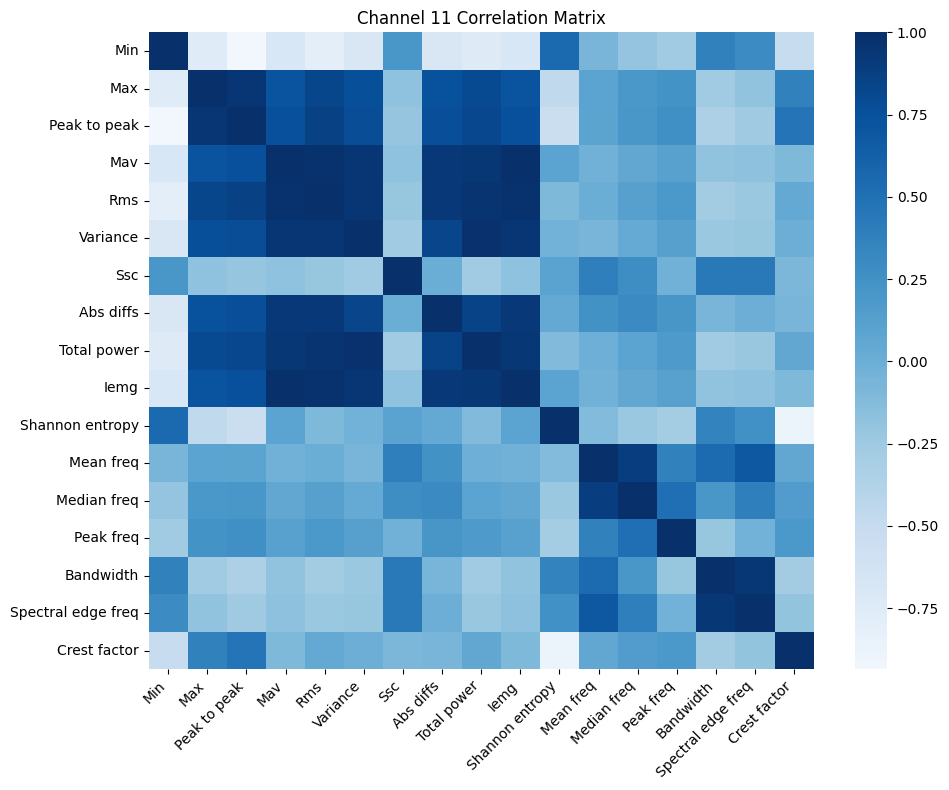

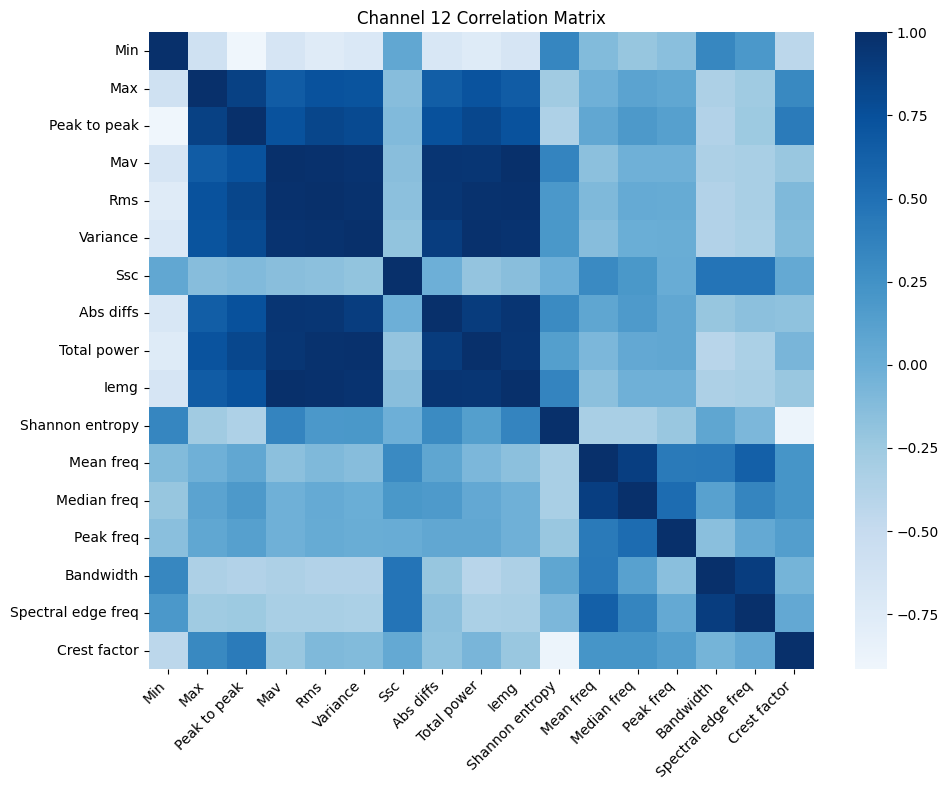

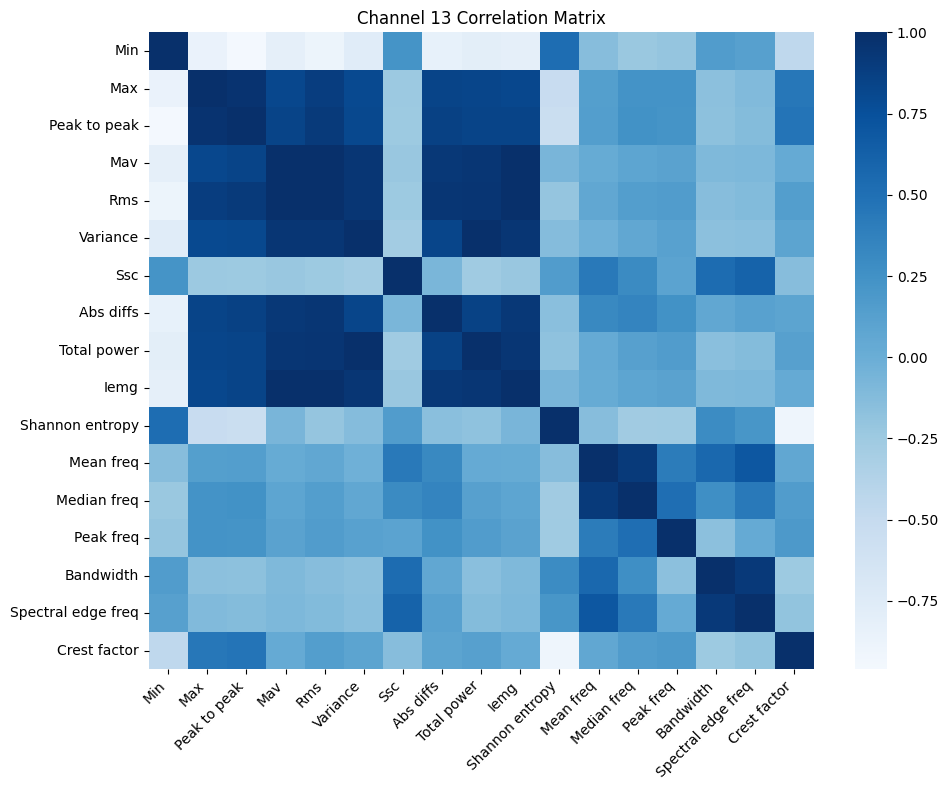

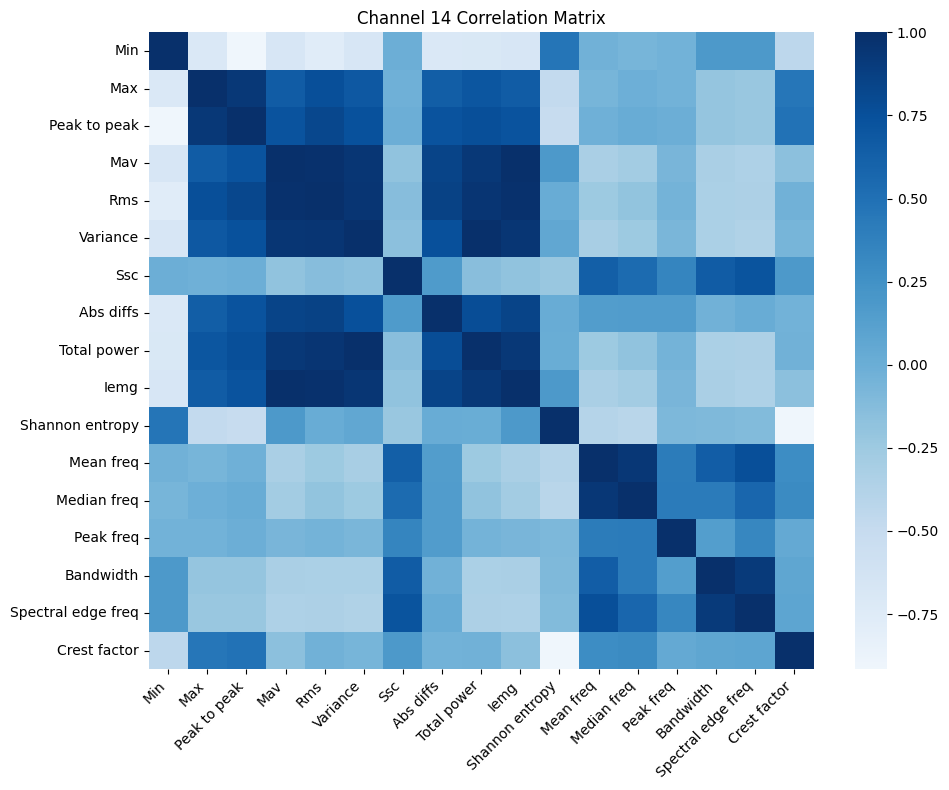

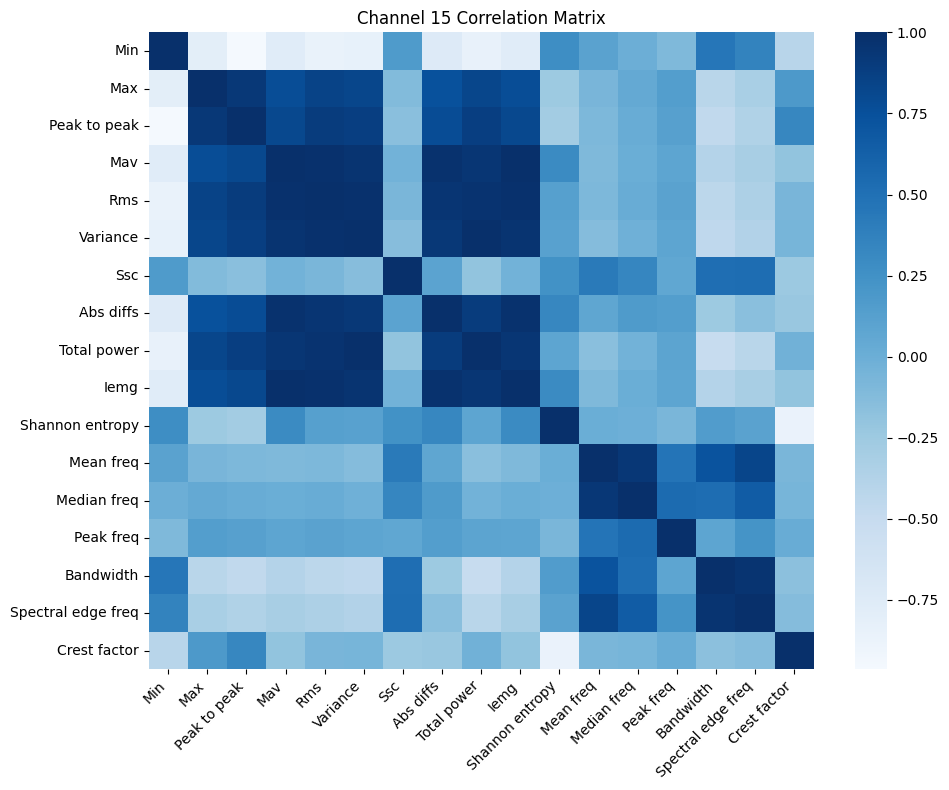

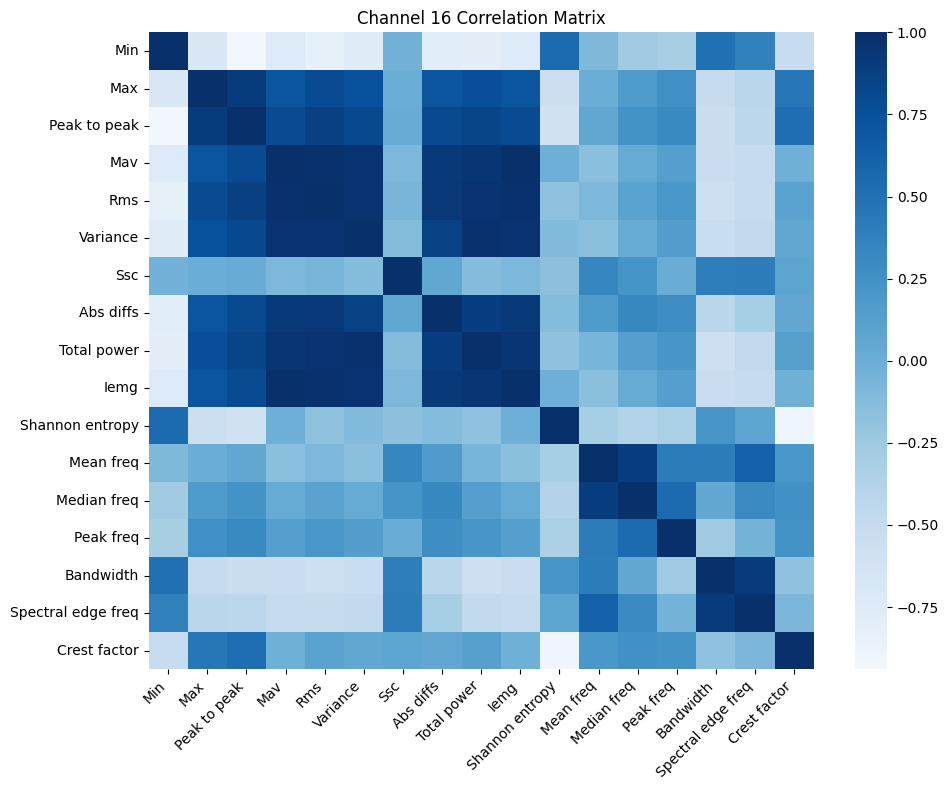

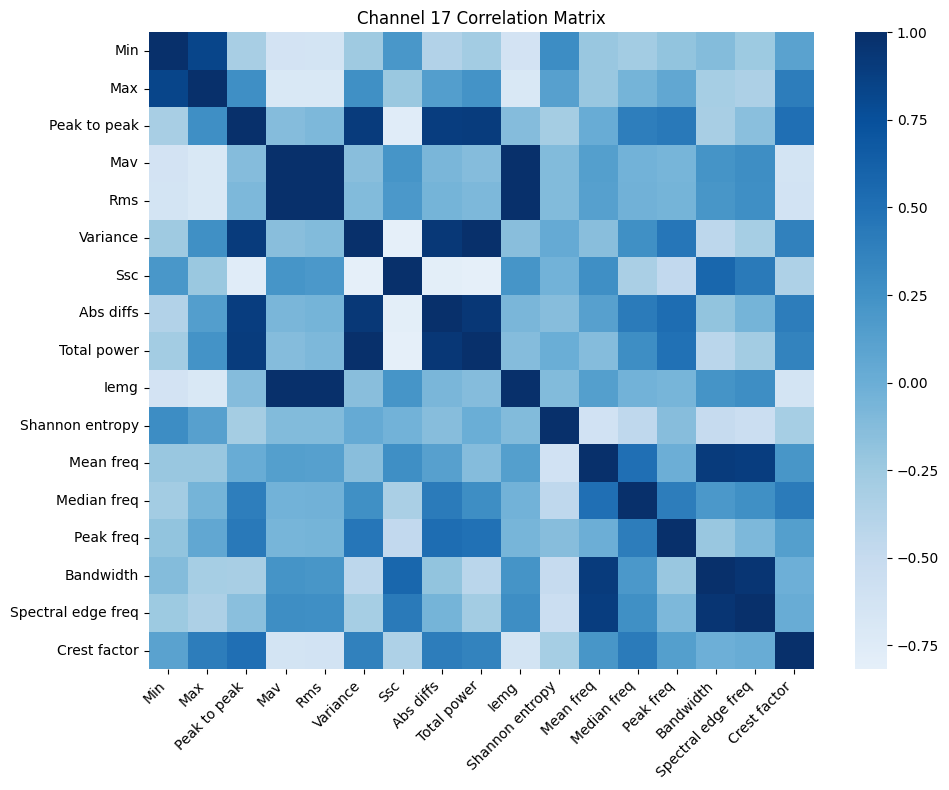

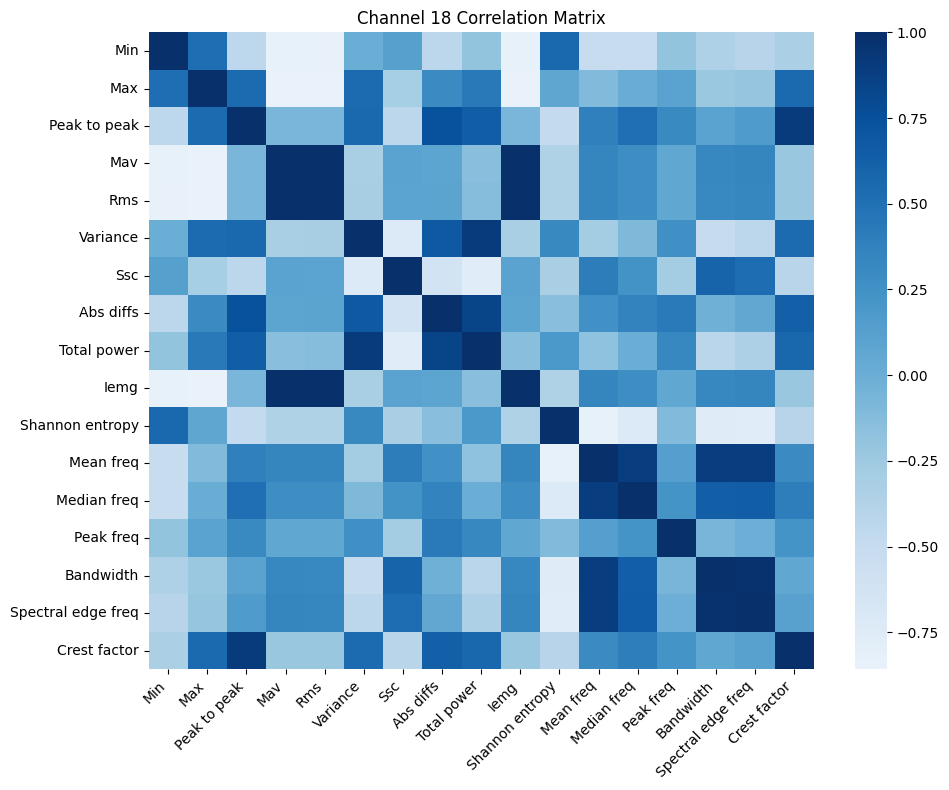

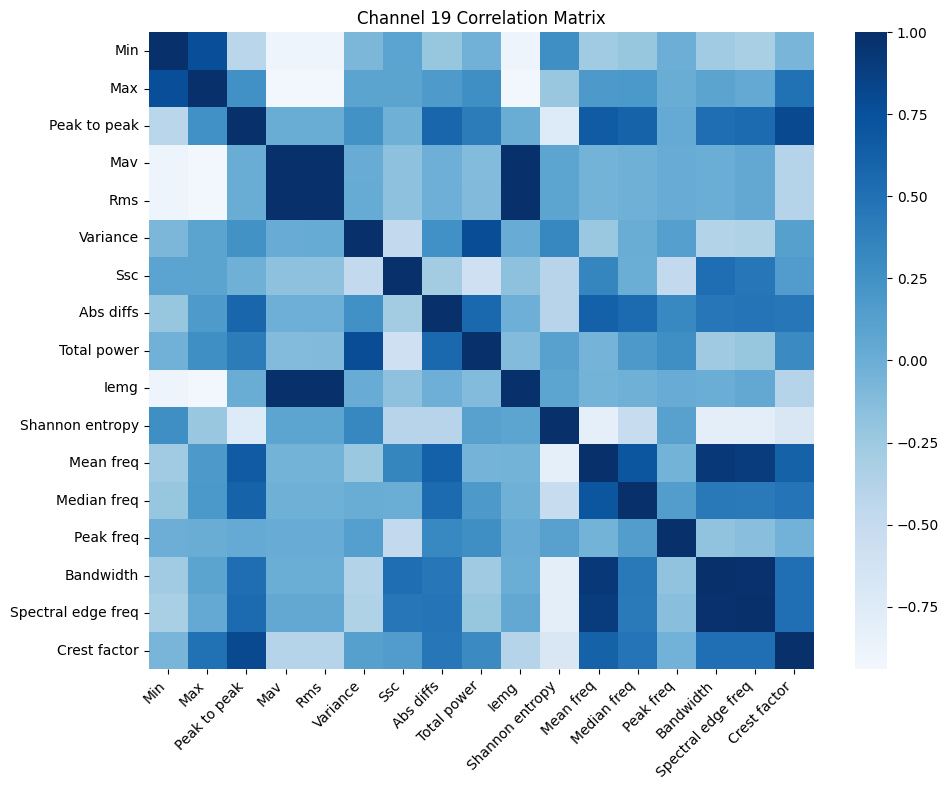

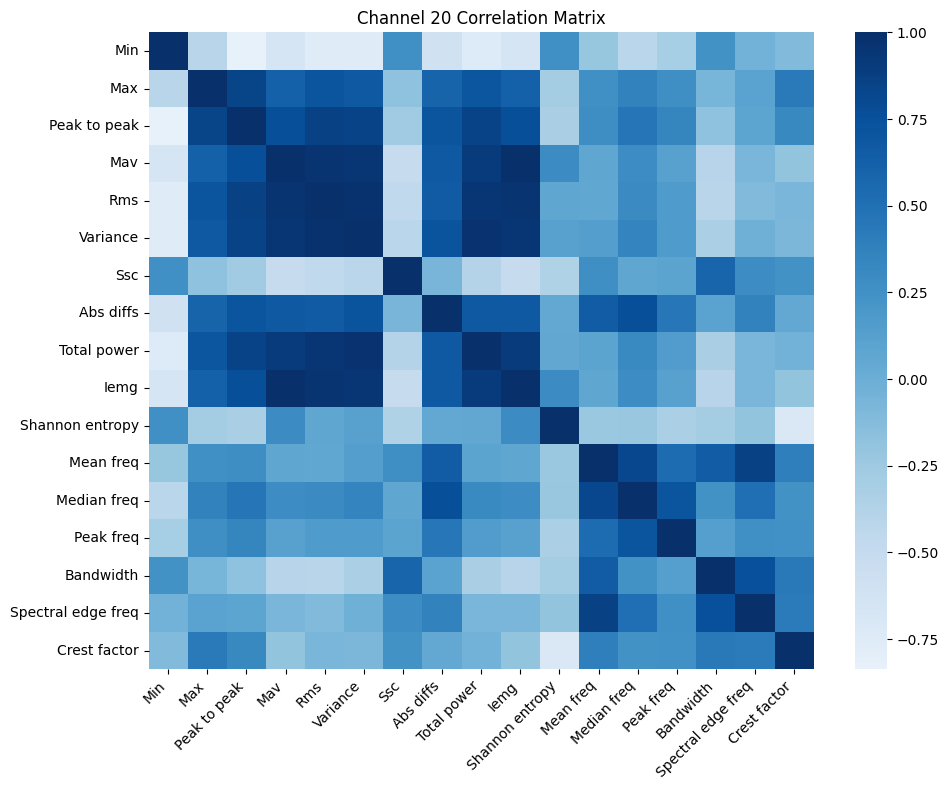

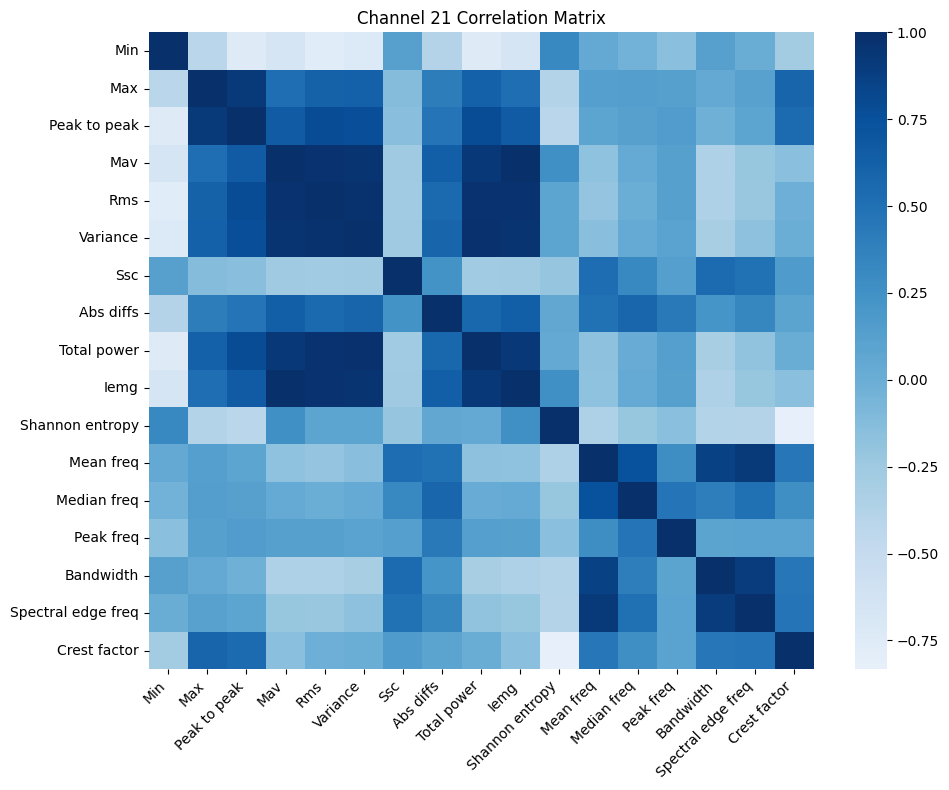

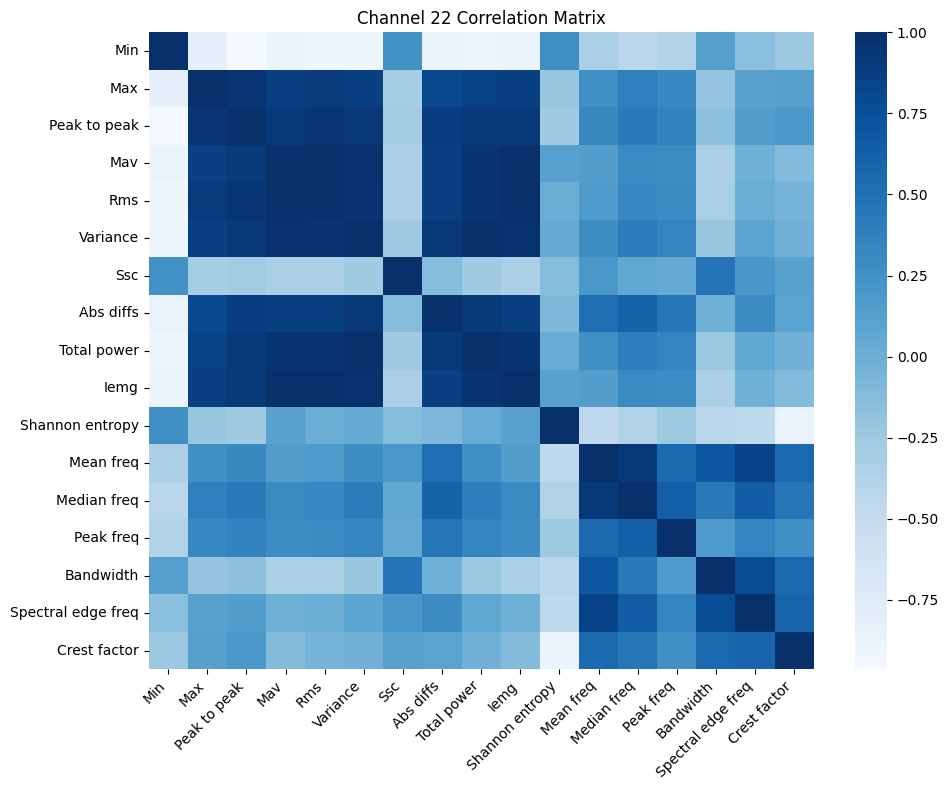

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def format_feature_name(name):
    return name.replace('_', ' ').capitalize()

num_features = 17

for i in range(22):
    channel_df = df.iloc[:, i*num_features+2:i*num_features+num_features+2]
    channel_df.columns = channel_df.columns.get_level_values(1)
    corr = channel_df.corr()

    formatted_labels = [format_feature_name(name) for name in corr.columns]
    
    plt.figure(figsize=(10, 8))

    ax = sns.heatmap(corr, cmap="Blues", center=0, 
                     xticklabels=formatted_labels, 
                     yticklabels=formatted_labels)
    
    plt.title("Channel " + str(i+1) + " Correlation Matrix")
    plt.xticks(rotation=45, ha='right')  
    plt.yticks(rotation=0) 
    plt.tight_layout()
    plt.show()

# Neural Network Feature Selection

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

x = df.drop(columns=['volume', 'substance'])
y = df[['substance', 'volume']]

combined_y = y['substance'].astype(str) + '_' + y['volume'].astype(str)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=combined_y, random_state=42)

y_train = y_train.astype(int)
y_test = y_test.astype(int)
    
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

C:\Users\chloe\AppData\Local\Temp\ipykernel_15476\802329423.py:4: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  x = df.drop(columns=['volume', 'substance'])


In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

x_train_t = torch.tensor(x_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32)
x_test_t  = torch.tensor(x_test_scaled,  dtype=torch.float32)
y_test_t  = torch.tensor(y_test.values,  dtype=torch.float32)

n_features = x_train_scaled.shape[1]
n_outputs  = y_train.shape[1]  

class Net(nn.Module):
    def __init__(self, n_features, n_outputs):
        super().__init__()
        self.fc1 = nn.Linear(n_features, 16)   # first layer (feature importance lives here)
        self.fc2 = nn.Linear(16, n_outputs)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        return self.fc2(x)

In [ ]:
feature_names = x_train.columns  

model = Net(n_features, n_outputs)

# Loss + optimizer
criterion = nn.MSELoss()   # if regression
optimizer = optim.Adam(model.parameters(), lr=1e-3)
l1_lambda = 1e-4   # strength of L1 penalty

for epoch in range(100):
    optimizer.zero_grad()
    outputs = model(x_train_t)

    loss = criterion(outputs, y_train_t)

    # add L1 penalty on first layer weights
    l1_penalty = l1_lambda * torch.norm(model.fc1.weight, 1)
    loss = loss + l1_penalty

    loss.backward()
    optimizer.step()

with torch.no_grad():
    weights = model.fc1.weight.abs().mean(dim=0)  # average across hidden units
    importance = weights.numpy()

feature_importance = list(zip(feature_names, importance))
feature_importance_sorted = sorted(feature_importance, key=lambda x: -x[0][0])

(22, 'min'): 0.0710
(22, 'max'): 0.0566
(22, 'peak_to_peak'): 0.0682
(22, 'mav'): 0.0712
(22, 'rms'): 0.0754
(22, 'variance'): 0.0612
(22, 'ssc'): 0.0590
(22, 'abs_diffs'): 0.0608
(22, 'total_power'): 0.0573
(22, 'iemg'): 0.0810
(22, 'shannon_entropy'): 0.0663
(22, 'mean_freq'): 0.0484
(22, 'median_freq'): 0.0502
(22, 'peak_freq'): 0.0536
(22, 'bandwidth'): 0.0668
(22, 'spectral_edge_freq'): 0.0567
(22, 'crest_factor'): 0.0564
(21, 'min'): 0.0612
(21, 'max'): 0.0545
(21, 'peak_to_peak'): 0.0725
(21, 'mav'): 0.0561
(21, 'rms'): 0.0789
(21, 'variance'): 0.0753
(21, 'ssc'): 0.0680
(21, 'abs_diffs'): 0.0456
(21, 'total_power'): 0.0663
(21, 'iemg'): 0.0642
(21, 'shannon_entropy'): 0.0574
(21, 'mean_freq'): 0.0506
(21, 'median_freq'): 0.0598
(21, 'peak_freq'): 0.0690
(21, 'bandwidth'): 0.0581
(21, 'spectral_edge_freq'): 0.0655
(21, 'crest_factor'): 0.0675
(20, 'min'): 0.0734
(20, 'max'): 0.0654
(20, 'peak_to_peak'): 0.0549
(20, 'mav'): 0.0627
(20, 'rms'): 0.0543
(20, 'variance'): 0.0635
(20,

In [24]:
channel_feature_importances = []

for i in range(22):
    channel_df = pd.DataFrame(feature_importance_sorted[i*num_features:(i+1)*num_features], columns=["Feature", "Importance"])
    channel_df = channel_df.sort_values(by='Importance', ascending=False)
    channel_df.reset_index(drop=True, inplace=True)
    channel_feature_importances.append(channel_df)

channel_feature_importances = channel_feature_importances[::-1]


In [25]:
channel_feature_importances[0]

,Feature,Importance
0,"(1, spectral_edge_freq)",0.068885
1,"(1, crest_factor)",0.067015
2,"(1, mean_freq)",0.064506
3,"(1, bandwidth)",0.064313
4,"(1, peak_to_peak)",0.062880
5,"(1, min)",0.062599
6,"(1, ssc)",0.061525
7,"(1, shannon_entropy)",0.061381
8,"(1, mav)",0.060634
9,"(1, total_power)",0.059710


In [ ]:
feature_names_no_col = { "min" : 0, 
                         "max" : 1, 
                         "peak_to_peak" : 2, 
                         "mav" : 3, 
                         "rms" : 4, 
                         "variance" : 5, 
                         "ssc" : 6, 
                         "abs_diffs" : 7, 
                         "total_power" : 8, 
                         "iemg" : 9, 
                         "shannon_entropy" : 10, 
                         "mean_freq" : 11, 
                         "median_freq" : 12, 
                         "peak_freq" : 13, 
                         "bandwidth" : 14,
                         "spectral_edge_freq" : 15,
                         "crest_factor" : 16}

feature_rank_counts = [[0] * 17 for _ in range(17)]

for channel_df in channel_feature_importances:    
    for i, row in channel_df.iterrows():
        feature = feature_names_no_col[row['Feature'][1]]
        feature_rank_counts[feature][i] += 1  

# No PCA

In [ ]:
x = df.drop(columns=['volume', 'substance'])
y = df[['substance', 'volume']]
exact_accuracies, label_accuracies = models.train_multioutput_models(x, y, class_map, random_state=42, show_cm=False, show_metrics=True)

C:\Users\chloe\AppData\Local\Temp\ipykernel_26336\2590886700.py:1: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  x = df.drop(columns=['volume', 'substance'])


KeyboardInterrupt: 

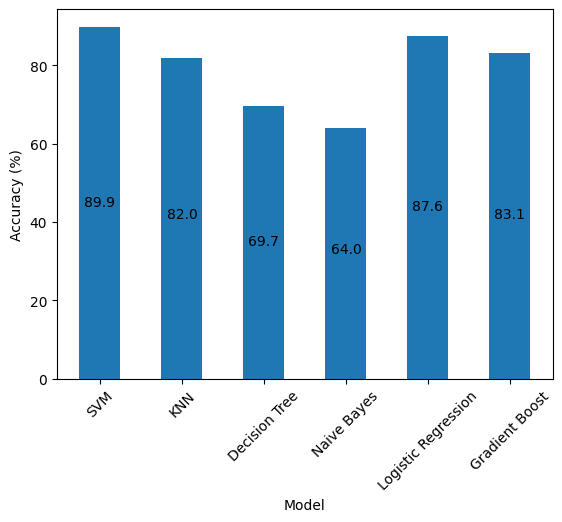

In [ ]:
results.plot_acc(exact_accuracies)

# PCA

In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

x = df.drop(columns=['volume', 'substance'])
y = df[['substance', 'volume']]

x_train, x_test, y_train, y_test = models.make_split(x, y, 42)

pca = PCA(n_components=0.9)
x_train_pca = pca.fit_transform(x_train)
x_test_pca  = pca.transform(x_test)

print("Original shape:", x_train.shape)
print("Reduced shape (PCA):", x_train_pca.shape)
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", np.sum(pca.explained_variance_ratio_))

C:\Users\chloe\AppData\Local\Temp\ipykernel_26336\1417016127.py:5: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  x = df.drop(columns=['volume', 'substance'])


Original shape: (356, 308)
Reduced shape (PCA): (356, 33)
Explained variance ratio: [0.24546854 0.16640117 0.09511255 0.07784059 0.05476829 0.03714129
 0.03027371 0.02139207 0.01777226 0.01509405 0.01224187 0.01173641
 0.01053844 0.00911918 0.00851423 0.00784402 0.00748271 0.00681191
 0.00597853 0.00556684 0.00542757 0.00520707 0.00493821 0.00451796
 0.00434848 0.00419896 0.00413206 0.00406785 0.00378137 0.00355927
 0.00332705 0.00315677 0.00305686]
Total explained variance: 0.9008181862481284


In [ ]:
from src.models import multioutput_models
from sklearn.base import clone

def train_pca_models(x_train, x_test, y_train, y_test, substance_names):
    acc = []
    per_label_acc = []
    
    models_copy = [[name, clone(model)] for name, model in multioutput_models]

    substance_labels = [
        (k[5:] if k.lower().startswith('redu ') else k).capitalize()
        for k in substance_names.keys()
    ]
    
    for model in models_copy:
        model[1].fit(x_train, y_train)
        y_pred = model[1].predict(x_test)
    
        # Exact match accuracy (all labels correct)
        exact_match_accuracy = np.mean(np.all(y_test.values == y_pred, axis=1))
    
        # Per-label accuracy
        per_label_accuracy = (y_test == y_pred).mean(axis=0)
    
        acc.append(exact_match_accuracy * 100)
        per_label_acc.append(per_label_accuracy * 100)

    return acc, per_label_acc

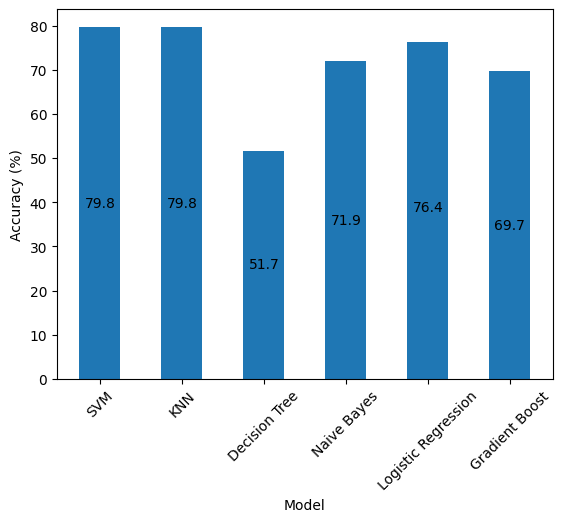

In [ ]:
pca_accuracies, pca_label_accuracies = train_pca_models(x_train_pca, x_test_pca, y_train, y_test, class_map)

results.plot_acc(pca_accuracies)

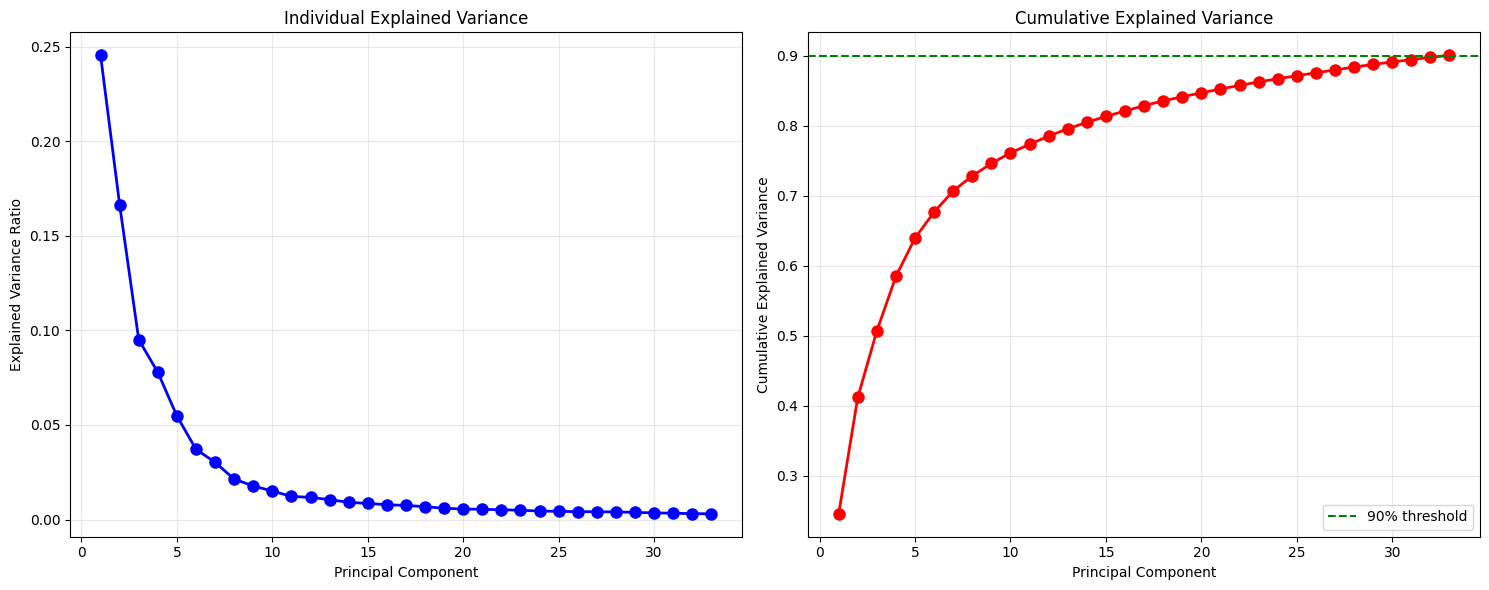

In [ ]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Individual explained variance
ax1.plot(range(1, len(pca.explained_variance_ratio_) + 1), 
         pca.explained_variance_ratio_, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Explained Variance Ratio')
ax1.set_title('Individual Explained Variance')
ax1.grid(True, alpha=0.3)

# Cumulative explained variance
ax2.plot(range(1, len(pca.explained_variance_ratio_) + 1), 
         np.cumsum(pca.explained_variance_ratio_), 'ro-', linewidth=2, markersize=8)
ax2.axhline(y=0.9, color='g', linestyle='--', label='90% threshold')
ax2.set_xlabel('Principal Component')
ax2.set_ylabel('Cumulative Explained Variance')
ax2.set_title('Cumulative Explained Variance')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

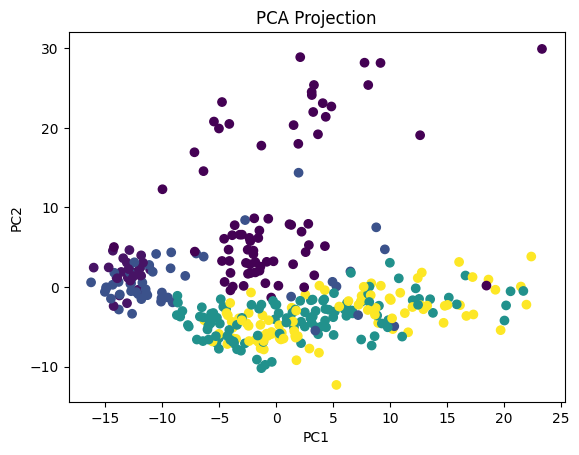

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(x_train_pca[:,0], x_train_pca[:,1], c=y_train['volume'], cmap='viridis')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection")
plt.show()

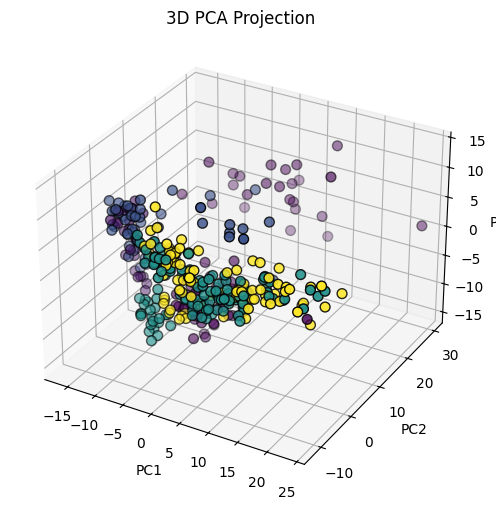

In [ ]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

# scatter plot in 3D
ax.scatter(
    x_train_pca[:,0], x_train_pca[:,1], x_train_pca[:,2],
    c=y_train['volume'], cmap='viridis', edgecolor='k', s=50
)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("3D PCA Projection")

plt.show()